# Difference-in-Differences Graph

## 1. Imports and Data Loading

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels.panel import PanelOLS

In [30]:
column_dtypes = {
    "code": str,
    "treatment": int,
    "year": int,
    "post": int,
    "poverty_indicator": int,
}

df = pd.read_csv("data/clean_hcv_data.csv", dtype=column_dtypes)
df["did_interaction"] = df["treatment"] * df["post"]
df.head()

,program_label,program,entities,code,number_reported,rent_per_month,hh_income,tpoverty,treatment,year,post,poverty_indicator,did_interaction
0,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000401,48113000401,39,297,11131,38,1,2014,0,1,0
1,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000405,48113000405,17,268,10446,40,1,2014,0,1,0
2,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000500,48113000500,25,202,8242,17,1,2014,0,0,0
3,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000601,48113000601,17,336,12377,35,1,2014,0,1,0
4,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000800,48113000800,123,326,11988,27,1,2014,0,0,0


## 2. Refit the DiD Regression
 

In [31]:
reg_df = df.set_index(["code", "year"])

model = PanelOLS(
    reg_df["number_reported"],
    reg_df[["did_interaction", "hh_income", "rent_per_month", "tpoverty"]],
    entity_effects=True,
    time_effects=True,
)
results = model.fit(cov_type="clustered", cluster_entity=True)
did_coef = results.params["did_interaction"]
print(f"DiD coefficient: {did_coef:.4f}")

DiD coefficient: -11.2022


## 3. Build the Adjusted Series

 

In [32]:
reg_df["resid"] = results.resids.values
reg_df["plot_y"] = reg_df["resid"] + did_coef * reg_df["did_interaction"]

## 4. Yearly Group Means with 95% Confidence Intervals

In [33]:
flat = reg_df.reset_index()

agg = (
    flat.groupby(["year", "treatment"])["plot_y"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
agg["se"] = agg["std"] / np.sqrt(agg["count"])
agg["ci_low"] = agg["mean"] - 1.96 * agg["se"]
agg["ci_high"] = agg["mean"] + 1.96 * agg["se"]
agg["group"] = agg["treatment"].map({0: "Control (Houston)", 1: "Treatment (Dallas)"})
agg

,year,treatment,mean,std,count,se,ci_low,ci_high,group
0,2014,0,0.268320,18.867639,344,1.017275,-1.725539,2.262179,Control (Houston)
1,2014,1,-0.289348,23.626775,319,1.322845,-2.882125,2.303429,Treatment (Dallas)
2,2015,0,-2.261856,15.997238,343,0.863770,-3.954844,-0.568867,Control (Houston)
3,2015,1,2.535348,24.289858,306,1.388559,-0.186227,5.256923,Treatment (Dallas)
4,2016,0,-0.562409,14.936035,340,0.810020,-2.150048,1.025231,Control (Houston)
5,2016,1,0.643835,20.682961,297,1.200147,-1.708454,2.996123,Treatment (Dallas)
6,2017,0,2.535459,13.322978,345,0.717285,1.129580,3.941338,Control (Houston)
7,2017,1,-3.058508,16.311480,286,0.964518,-4.948964,-1.168053,Treatment (Dallas)
8,2018,0,-1.121478,10.861511,347,0.583076,-2.264308,0.021352,Control (Houston)
9,2018,1,-9.797270,13.607852,277,0.817617,-11.399798,-8.194741,Treatment (Dallas)


## 5. Difference-in-Differences Graph
 

In [34]:
sns.set_style("whitegrid")
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "axes.titleweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

color_treat = "#D55E00"
color_ctrl = "#0072B2"

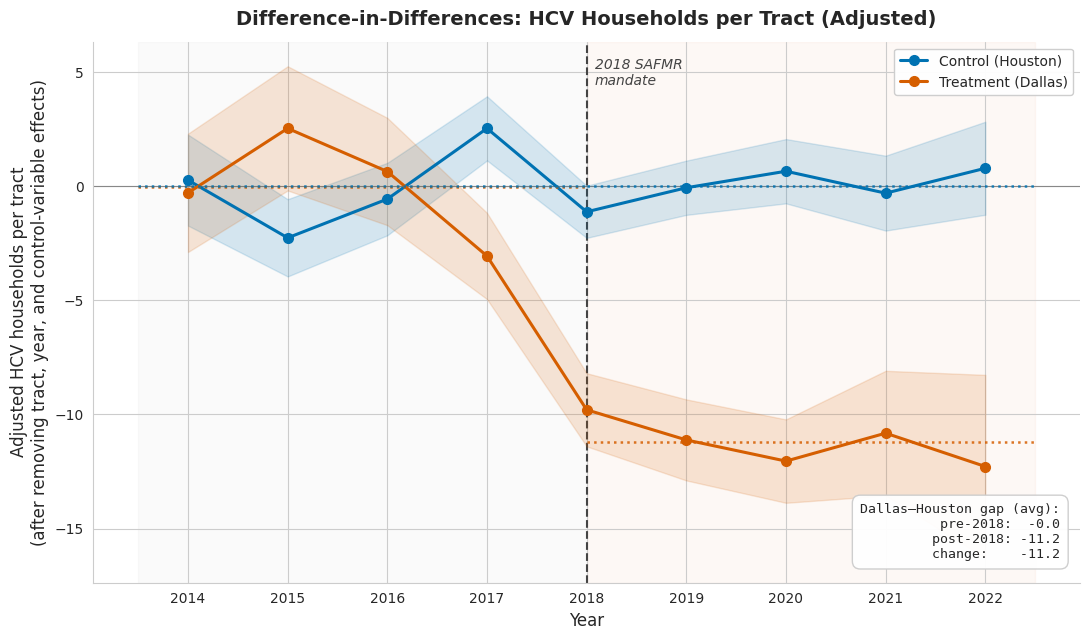

Pre-2018 gap:  -0.04
Post-2018 gap: -11.20
Change:        -11.17
Regression DiD coefficient: -11.20


In [35]:
# Pre/post group averages (for horizontal reference lines and info box)
policy_year = 2018
pre_mask = agg["year"] < policy_year
post_mask = agg["year"] >= policy_year
t_pre = agg.loc[pre_mask & (agg["treatment"] == 1), "mean"].mean()
c_pre = agg.loc[pre_mask & (agg["treatment"] == 0), "mean"].mean()
t_post = agg.loc[post_mask & (agg["treatment"] == 1), "mean"].mean()
c_post = agg.loc[post_mask & (agg["treatment"] == 0), "mean"].mean()
gap_pre = t_pre - c_pre
gap_post = t_post - c_post
gap_change = gap_post - gap_pre

fig, ax = plt.subplots(figsize=(11, 6.5))

for group_label, color in [
    ("Control (Houston)", color_ctrl),
    ("Treatment (Dallas)", color_treat),
]:
    sub = agg[agg["group"] == group_label].sort_values("year")
    ax.plot(
        sub["year"],
        sub["mean"],
        marker="o",
        linewidth=2.2,
        markersize=7,
        color=color,
        label=group_label,
        zorder=3,
    )
    ax.fill_between(
        sub["year"],
        sub["ci_low"],
        sub["ci_high"],
        color=color,
        alpha=0.15,
        zorder=2,
    )

# Pre/post group-average horizontal reference lines (dotted)
ax.hlines(
    t_pre,
    2013.5,
    policy_year,
    colors=color_treat,
    linestyles=":",
    linewidth=1.8,
    alpha=0.85,
    zorder=4,
)
ax.hlines(
    c_pre,
    2013.5,
    policy_year,
    colors=color_ctrl,
    linestyles=":",
    linewidth=1.8,
    alpha=0.85,
    zorder=4,
)
ax.hlines(
    t_post,
    policy_year,
    2022.5,
    colors=color_treat,
    linestyles=":",
    linewidth=1.8,
    alpha=0.85,
    zorder=4,
)
ax.hlines(
    c_post,
    policy_year,
    2022.5,
    colors=color_ctrl,
    linestyles=":",
    linewidth=1.8,
    alpha=0.85,
    zorder=4,
)

ax.axvline(policy_year, color="#444444", linestyle="--", linewidth=1.5, zorder=1)
ax.axhline(0, color="#888", linewidth=0.8, zorder=1)

ymin, ymax = ax.get_ylim()
ax.text(
    policy_year + 0.08,
    ymax - (ymax - ymin) * 0.03,
    "2018 SAFMR\nmandate",
    fontsize=10,
    color="#444444",
    va="top",
    ha="left",
    style="italic",
)

ax.axvspan(2013.5, policy_year, color="gray", alpha=0.04, zorder=0)
ax.axvspan(policy_year, 2022.5, color="#D55E00", alpha=0.04, zorder=0)

# Info box (averaged gap, clearly labeled)
ax.text(
    0.98,
    0.04,
    f"Dallas\u2013Houston gap (avg):\n  pre-2018:  {gap_pre:+.1f}\n  post-2018: {gap_post:+.1f}\n  change:    {gap_change:+.1f}",
    transform=ax.transAxes,
    fontsize=9.5,
    va="bottom",
    ha="right",
    family="monospace",
    bbox=dict(
        boxstyle="round,pad=0.6", facecolor="white", edgecolor="#cccccc", alpha=0.95
    ),
)

ax.set_title(
    "Difference-in-Differences: HCV Households per Tract (Adjusted)",
    fontsize=14,
    pad=12,
)
ax.set_xlabel("Year")
ax.set_ylabel(
    "Adjusted HCV households per tract\n(after removing tract, year, and control-variable effects)",
)
ax.legend(loc="upper right", frameon=True, framealpha=0.95, fontsize=10)
ax.set_xticks(range(2014, 2023))

plt.tight_layout()
plt.show()

print(f"Pre-2018 gap:  {gap_pre:+.2f}")
print(f"Post-2018 gap: {gap_post:+.2f}")
print(f"Change:        {gap_change:+.2f}")
print(f"Regression DiD coefficient: {did_coef:+.2f}")